---
title: Bayesian HMM GLM Improved (latest)
subtitle: Poisson HMM with new covariates
description: |
       This notebooks is an improving of the Bayesian HMM GLM's notebook used for the thesis. There are two more variables in the transition matrix and in the initial probabilities
format: html
jupyter: python3
editor_options:
       chunk_output_type: inline
author: ["Erik De Luca"]
categories: ["Pyro", "Python", "HMM", "Bayesian Models", "Viterbi Algorithm", "GLM"]
date: 2025-10-06
draft: false
---



## Import and clean data
Import functions and data into the notebook. 
The data is located in the *data* folder, while the functions are in the *python* folder. 
To enhance the readability of the notebook and reduce code redundancy, certain functions are organized into python files and imported as needed.

In [1]:
import sys
from pyprojroot import here

root_dir = str(here())
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# data manipulation
import pandas as pd
import numpy as np
import torch

# modelsp
from pyprojroot import here
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, TraceEnum_ELBO, config_enumerate
from pyro.optim import Adam

# data visualization
import matplotlib.pyplot as plt
import plotnine as pn

# plot settings
from matplotlib import font_manager as fm
from cycler import cycler

# constants and configurations
import config as C

# personal functions
import python.hmm_glm_model as hmm_glm
import python.hmm_glm_viterbi as viterbi
import python.hmm_glm_plots as hmm_pl

# color parameters
plt.rcParams["axes.prop_cycle"] = cycler(color=list(C.STATE_PALETTE.values()))
plt.rcParams['figure.facecolor'] = C.BG_COLOR
fm.fontManager.addfont(here(C.FONT_PATH))

df = pd.read_csv(here("data/recent_donations.csv"))
df

,unique_number,class_year,birth_year,first_donation_year,gender,y_2009,y_2010,y_2011,y_2012,y_2013,y_2014,y_2015,y_2016,y_2018,y_2019,y_2017,y_2020,y_2021,y_2022,y_2023
0,26308560,"(1960,1970]",1965,1985,M,0,0,0,0,0,0,0,0,0,0,0,1,1,3,1
1,26309283,"(1960,1970]",1966,2002,M,2,1,2,2,1,1,3,3,4,1,3,3,3,3,4
2,26317365,"(1960,1970]",1961,1984,M,4,2,3,3,3,4,3,3,2,3,3,2,0,1,0
3,26318451,"(1960,1970]",1967,1989,M,0,3,3,4,4,4,2,3,3,1,2,3,1,0,0
4,26319465,"(1960,1970]",1964,1994,F,1,2,2,1,2,1,1,0,0,2,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9231,27220599,"(1970,1980]",1980,2022,M,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0
9232,27220806,"(2000,2010]",2002,2022,M,0,0,0,0,0,0,0,0,0,0,0,0,0,2,3
9233,27221247,"(1990,2000]",2000,2022,F,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0
9234,27221274,"(1960,1970]",1966,2022,F,0,0,0,0,0,0,0,0,0,0,0,0,0,2,3


### Data Preparation

Here, we're setting the different dataframes used to train the model.
At the end, we're going to obtain 4 dataframes:
1. Initial probabilities - containing covariates, useful for a first clustering of the donors, before to observe any donation;
2. Transition matrix - covariates that lead the donor to change its behaviour, e.g. pass from a frequent donor to a non donor;
3. Emission - covariates that indicate how much a donor is going to donate, the covariates' behaviour can change with the state of the donor;
4. Number of donations - a dataset with the number of donations by year and donor.

The numeric covariates as 'first_donation_year' and 'birth_year' are normalized to avoid an over-weighting of the coefficients on them.
'gender_code' and 'covid_year' variables are coded into 0 and 1. 'covid_year' is a proxy for the years with the Covid: 2020, 2021 and 2022. This variable helps us to analyze how the behaviour in the donor changed along those years.

The data preparation is started with Pandas, then it passes to NumPy for multidimensional arrays and a copy of them is done in torch for the Pyro's models and Viterbi's function

In [3]:
# --- 1. Extract Observations and Lagged Donations ---
all_year_cols = sorted([c for c in df.columns if c.startswith("y_")])
year_cols = all_year_cols[1:]
T = len(year_cols)

# Fill missing values and split into current observations and previous year's donations
obs_full = df[all_year_cols].fillna(0).to_numpy(dtype=int)
obs = obs_full[:, 1:]
donation_py = obs_full[:, :-1]

# --- 2. Fixed Covariates (Initial State Probabilities) ---
df["gender_code"] = (df["gender"] == "F").astype(int)

# Normalize years using mean and standard deviation
birth_year_mean, birth_year_std = df["birth_year"].mean(), df["birth_year"].std()
df["birth_year_norm"] = (df["birth_year"] - birth_year_mean) / birth_year_std

first_don_mean, first_don_std = df["first_donation_year"].mean(), df["first_donation_year"].std()
df["first_donation_year_norm"] = (df["first_donation_year"] - first_don_mean) / first_don_std

cov_init = df[["first_donation_year_norm", "birth_year_norm", "gender_code"]].to_numpy()

# --- 3. Dynamic Covariates (Transitions and Emissions) ---
years_num = np.array([int(c[2:]) for c in year_cols])

# Calculate age for each donor across all years
ages = years_num[None, :] - df["birth_year"].to_numpy()[:, None]

# Covid dummy variable
covid_mask = np.isin(years_num, [2020, 2021, 2022]).astype(float)
covid_years = np.tile(covid_mask, (len(df), 1))

# Age binning and one-hot encoding (dropping 18-24 as baseline)
age_bins = np.array([18, 25, 35, 45, 55, 60, 65, 75])
ages_binned = np.clip(np.digitize(ages, age_bins, right=False), 1, len(age_bins) - 1)
ages_onehot = np.eye(len(age_bins) - 1)[ages_binned - 1][:, :, 1:]

# Common components for concatenation
intercept_tile = np.ones((ages_onehot.shape[0], ages_onehot.shape[1], 1))
gender_tile = np.repeat(df["gender_code"].to_numpy()[:, None], T, axis=1)[:, :, None]

# --- 4. Assembly of Covariate Tensors ---
cov_tran = np.concatenate([
    ages_onehot,
    covid_years[:, :, None],
    donation_py[:, :, None]
], axis=2)

cov_emission = np.concatenate([
    intercept_tile,
    gender_tile,
    ages_onehot,
    covid_years[:, :, None]
], axis=2)

# --- 5. Convert to Torch Tensors ---
obs_torch = torch.tensor(obs, dtype=torch.long)
cov_init_torch = torch.tensor(cov_init, dtype=torch.float)
cov_tran_torch = torch.tensor(cov_tran, dtype=torch.float)
cov_emiss_torch = torch.tensor(cov_emission, dtype=torch.float)

print(f"Observations: {obs_torch.shape}")
print(f"Pi Covariates: {cov_init_torch.shape}")
print(f"Transition Covariates: {cov_tran_torch.shape}")
print(f"Emission Covariates: {cov_emiss_torch.shape}")

Observations: torch.Size([9236, 14])
Pi Covariates: torch.Size([9236, 3])
Transition Covariates: torch.Size([9236, 14, 8])
Emission Covariates: torch.Size([9236, 14, 9])


We are planning to create two models:

- **Development Model**: This model will be used for development purposes, where we will split the observations into training and testing sets. We will evaluate the model's bias and variance to ensure its reliability and performance.

- **Production Model**: This model will be integrated into the dashboard, with the primary goal of achieving the best possible predictions. In this case, more data will enhance the model's predictive power and accuracy. So, we will use the full dataset to train it.

In [4]:
# stratified split 90/10 by gender × age-bin (age at t=0)
N, T = obs_torch.shape
age0 = ages[:, 0]                                          # (N,)
age0_bin = np.digitize(age0, age_bins, right=False)        # 1..7
age0_bin = np.clip(age0_bin, 1, len(age_bins))
labels = np.array([f"{int(g)}-{int(b)}" for g, b in zip(df["gender_code"].to_numpy(), age0_bin)])

rng = np.random.default_rng(1)
indices = np.arange(N)
test_idx = []
for lab in np.unique(labels):
    idx_lab = indices[labels == lab]
    if idx_lab.size == 0:
        continue
    n_test = max(1, int(np.ceil(0.10 * idx_lab.size)))
    pick = rng.choice(idx_lab, size=n_test, replace=False)
    test_idx.append(pick)

test_idx = np.sort(np.concatenate(test_idx))
train_idx = np.setdiff1d(indices, test_idx)

# subset train and test
# torch
obs_train_torch = obs_torch[train_idx]
xpi_train_torch = cov_init_torch[train_idx]
xA_train_torch  = cov_tran_torch[train_idx]
xem_train_torch = cov_emiss_torch[train_idx]
# numpy
obs_train = obs[train_idx]
xpi_train = cov_init[train_idx]
xA_train  = cov_tran[train_idx]
xem_train = cov_emission[train_idx]

# torch
obs_test_torch = obs_torch[test_idx]
xpi_test_torch = cov_init_torch[test_idx]
xA_test_torch  = cov_tran_torch[test_idx]
xem_test_torch = cov_emiss_torch[test_idx]
# numpy
obs_test = obs[test_idx]
xpi_test = cov_init[test_idx]
xA_test  = cov_tran[test_idx]
xem_test  = cov_emission[test_idx]


print(f"N train = {obs_train.shape[0]}, N test = {obs_test.shape[0]}")
print("emission (train):", xem_train.shape)
print("emission (test) :", xem_test.shape)

N train = 8306, N test = 930
emission (train): (8306, 14, 9)
emission (test) : (930, 14, 9)


Covariates names, useful for labeling the plots

In [5]:
age_years_levels = ["18-24","25-34","35-44","45-54","55-59","60-64", "+65"] # TODO: #2 improve age bins  
ref_age_level = "18-24"

cov_names_pi = {
    "first_donation_year_norm": "First Donation Year",
    "birth_year_norm": "Birth Year",
    "gender": "Gender",
}

# create column names for ages binned removing the base level
age_dict = {f"{lev}": f"Age: [{lev}]" for lev in age_years_levels if lev != ref_age_level}

cov_names_A = {}
cov_names_A.update(age_dict)
cov_names_A.update({
    "covid_years": "Covid Years",
    "donations_py": "Donations in PY",
})

cov_names_em = {
    "intercept": "Intercept",
    "gender": "Gender",
}
cov_names_em.update(age_dict)
cov_names_em["covid_years"] = "Covid Years"

## Model

Let $x^\pi_n \in \mathbb{R}^3$ encode the static initial covariates (`first_donation_year_norm`, `birth_year_norm`, `gender_code`), $x^A_{n,t} \in \mathbb{R}^8$ encode the dynamic transition covariates (six age-bin dummies excluding the 18-24 baseline, a `covid_years` indicator, and `donations_py`), and $x^{em}_{n,t} \in \mathbb{R}^9$ encode the emission covariates (`intercept`, `gender_code`, six age-bin dummies, and `covid_years`).

* **Hidden state** $z_{n,t} \in \{0,1,2\}$ (representing Resting/Non-Donor, Occasional Donor, Frequent Donor)
* **Observed count** $y_{n,t} \in \mathbb{N}$ (number of donations)

**Priors and Initialization**
Uniform priors are used for the base distributions, but a strongly diagonal initialization is applied in the variational guide to prevent the SVI optimizer from falling into uninterpretable local optima (e.g., label switching or ignoring state persistence).

* $\pi_{\text{base}} \sim \mathrm{Dirichlet}(\mathbf{1}_K)$
* $A_{\text{base}}[k,\cdot] \sim \mathrm{Dirichlet}(\mathbf{1}_K)$

**Slope parameters to learn**
* $W_\pi \in \mathbb{R}^{K \times 3}$ (Slopes for initial state probabilities)
* $W_A \in \mathbb{R}^{K \times K \times 8}$ (Slopes for state-to-state transition probabilities)
* $\beta_{em} \in \mathbb{R}^{K \times 9}$ (State-specific slopes for emission GLMs, where the first column acts as the intercept)

**Initial-state distribution**
$$
\Pr(z_{n,0}=k \mid x^\pi_n) = \mathrm{softmax}_k \big( \log \pi_{\text{base},k} + W_{\pi,k} \cdot x^\pi_n \big)
$$

**Transition distribution**
$$
\Pr(z_{n,t}=j \mid z_{n,t-1}=k, \ x^A_{n,t}) = \mathrm{softmax}_j \big( \log A_{\text{base},kj} + W_{A,kj} \cdot x^A_{n,t} \big)
$$

**Emission (State-specific Poisson GLM)**
$$
y_{n,t} \mid z_{n,t}=k \sim \mathrm{Poisson}\Big( \exp\big( x^{em}_{n,t} \cdot \beta_{em,k} \big) \Big)
$$

**Variational guide**
* Point-mass (Delta distribution) for $\pi_{\text{base}}$ and $A_{\text{base}}$.
* $A_{\text{base}}$ map is initialized with a strongly diagonal matrix ($A_{\text{init}} = I \cdot (K-1) + 1$) to encode the prior belief of state stability.
* $\pi_{\text{base}}$ map is initialized with an asymmetric array (e.g., $[0.6, 0.3, 0.1]$) to reflect the higher prevalence of inactive donors at $t=0$.
* All $W_\pi$, $W_A$, $\beta_{em}$ are deterministic Pyro parameters.

**Training**
* **Loss**: `TraceEnum_ELBO(max_plate_nesting=1)` for exact marginalization of the discrete latent states.
* **Optimizer**: `Adam({"lr": 2e-2})`
* **Iterations**: 2000 cycles (empirically validated to reach asymptotic convergence of the ELBO for this dataset).

In [6]:
K      = 3                      # Number of latent states
C_pi   = cov_init.shape[1]      # Initial-state covariates
C_A    = cov_tran.shape[2]      # Transition covariates
C_em   = cov_emission.shape[2]  # Emission covariates

# Asymmetric Dirichlet priors
alpha_pi = torch.ones(K)
alpha_A  = torch.ones((K, K))

# for the guide
# pi_init = torch.tensor([0.6, 0.3, 0.1])


@config_enumerate
def hmm_glm_improved(obs, x_pi, x_A, x_em):
    N, T = obs.shape

    # Priors for initial and transition distribution
    pi_base = pyro.sample("pi_base", dist.Dirichlet(alpha_pi))
    A_base  = pyro.sample("A_base",  dist.Dirichlet(alpha_A).to_event(1))
    log_pi_base = pi_base.log()
    log_A_base  = A_base.log()

    # Slope coefficients for initial and transition covariates (learnt)
    W_pi = pyro.param("W_pi", torch.zeros(K, C_pi))
    W_A  = pyro.param("W_A", torch.zeros(K, K, C_A))
    # GLM emission coefficients (learnt)
    beta_em = pyro.param("beta_em", torch.zeros(K, C_em))

    with pyro.plate("seqs", N):
        # Initial hidden state probabilities: depend on x_pi via W_pi
        logits0 = log_pi_base + (x_pi @ W_pi.T)
        z_prev = pyro.sample("z_0",
                             dist.Categorical(logits=logits0),
                             infer={"enumerate": "parallel"})

        # Emission at t=0: GLM on covariates x_em[:, 0, :]
        log_mu0 = (x_em[:, 0, :] * beta_em[z_prev, :]).sum(-1)
        pyro.sample("y_0", dist.Poisson(log_mu0.exp()), obs=obs[:, 0])

        # For t = 1 ... T-1, update state and emit
        for t in range(1, T):
            x_t = x_A[:, t, :]
            logitsT = (log_A_base[z_prev] + (W_A[z_prev] * x_t[:, None, :]).sum(-1))
            z_t = pyro.sample(f"z_{t}",
                             dist.Categorical(logits=logitsT),
                             infer={"enumerate": "parallel"})

            # Emission at time t
            log_mu_t = (x_em[:, t, :] * beta_em[z_t, :]).sum(-1)
            pyro.sample(f"y_{t}", dist.Poisson(log_mu_t.exp()), obs=obs[:, t])
            z_prev = z_t

#  GUIDE: Point-mass for pi_base and A_base, params for all slopes
def guide_hmm_glm_improved(obs, x_pi, x_A, x_em):
    pi_q = pyro.param(
        "pi_base_map",
        alpha_pi,
        constraint=dist.constraints.simplex
    )

    # Each row: simplex for state-to-state transitions
    # A_init = torch.eye(K) * (K - 1.) + 1.
    # A_init = A_init / A_init.sum(-1, keepdim=True)
    A_q = pyro.param(
        "A_base_map",
        alpha_A,
        constraint=dist.constraints.simplex
    )

    pyro.sample("pi_base", dist.Delta(pi_q).to_event(1))
    pyro.sample("A_base",  dist.Delta(A_q).to_event(2))


Training of the model, this part is run once and the stored into models folder. It takes 10 minutes with a Raspberry PI 5.

In [7]:
# cycles = 2000

# pyro.clear_param_store()
# svi = SVI(hmm_glm_improved, guide_hmm_glm_improved,
#           Adam({"lr": 2e-2}),
#           loss=TraceEnum_ELBO(max_plate_nesting=1))

# for step in range(cycles):
#     loss = svi.step(obs_torch, cov_init_torch, cov_tran_torch, cov_emiss_torch)
#     if step % round(cycles / 15) == 0:
#         print(f"{step:4d}  ELBO = {loss:,.0f}")

# param_path = here("models/hmm_glm_improved.pt")
# pyro.get_param_store().save(param_path)
# print(f"ParamStore saved in: {param_path}")

Each time, we load the parameters estimated by the model. This function reorder the states by the intercept coefficient of the emissions.

In [8]:
W_pi, W_A, pi_base, A_base, beta_em = hmm_glm.load_hmm_params(here("models/hmm_glm_improved.pt"))
# beta_em


## Viterbi Algorithm (with covariates and Poisson-GLM emissions)

For each donor $n=1..N$, find the MAP latent path $z_{0:T}^\ast$. This is an extension of the classic Viterbi algorithm, it has been adapted to our model structure.

**Parameterization (plug-in, posterior means)**
- Covariate-dependent initial distribution:
  - Logits for $\pi$: $\ell_\pi(x_\pi) = \log \pi_{\text{base}} + W_\pi x_\pi$
  - $\pi(x_\pi) = \text{softmax}(\ell_\pi(x_\pi))$
- Covariate-dependent transition matrix:
  - Logits for $A$ at time $t$: $\ell_A(x_{A,t})_{k\to j} = \log A_{\text{base}}[k,j] + \langle W_A[k,j,:], x_{A,t} \rangle$
  - $A(x_{A,t})[k,\cdot] = \text{softmax}_j\bigl(\ell_A(x_{A,t})_{k\to j}\bigr)$
- Emissions:
  - Poisson-GLM per state $k$: $\eta_k(t) = \beta_{em,k,0} + x_{\text{em},t}^T \beta_{em,k}$
  - $\lambda_k(t) = \exp\bigl(\eta_k(t)\bigr)$

**Dynamic Programming**
- Initialization ($t=0$):

$$
\delta_0(k)=\log \pi_k(x_\pi)+\log \text{Poisson}(y_0\mid \lambda_k(0)).
$$

- Recursion for $t=1,\dots,T$:

$$
\delta_t(j)=\max_k\bigl[\delta_{t-1}(k)+\log A_{k\to j}(x_{A,t})\bigr]+\log \text{Poisson}(y_t\mid \lambda_j(t)),
$$

$$
\psi_t(j)=\arg\max_k\bigl[\delta_{t-1}(k)+\log A_{k\to j}(x_{A,t})\bigr].
$$

- Back-tracking:

$$
z_T^\ast=\arg\max_k \delta_T(k),
$$

$$
z_{t-1}^\ast=\psi_t\bigl(z_t^\ast\bigr)\quad\text{for }t=T,\dots,1.
$$


In [9]:
paths = viterbi.viterbi_paths_glm(
    obs,
    cov_init,    # (N,C_pi)
    cov_tran,    # (N,T,C_A)
    cov_emission,    # (N,T,C_em)
    here("models/hmm_glm_improved.pt")
)
switch_rate = (paths[:, 1:] != paths[:, :-1]).any(1).mean()
print(f"switch rate = {switch_rate:.2%}")

switch rate = 88.62%


The loss (negative ELBO) steadily decreases from ≈166k to ≈115k and then plateaus, indicating that the optimization has successfully converged.

**Initial-state distribution** $\pi$
State 0 dominates (**80%**), followed by state 1 (**12.5%**); state 2 is the rarest (**7.5%**). The vast majority of donors enter the observation window in an inactive state.

**Transition matrix** $A$ 
- Strong self-persistence: $P(0 \rightarrow 0) = 0.90$, $P(1 \rightarrow 1) = 0.99$, $P(2 \rightarrow 2) = 0.99$.    
- Cross-state moves are very rare; once donors enter a specific state, they exhibit a strong behavioral inertia and tend to remain there.

**Poisson rates** $\beta_{em}$
- **State 0 (Non-Donor):** Most of the $\beta$ coefficients are negative and the intercept is strongly negative (≈ -6); therefore, the exponential (the expected number of donations) is approximately zero.
- **State 1 (Occasional Donor):** Donors in this state were more prone to donate during the COVID-19 pandemic and typically fall into the middle age brackets.
- **State 2 (Frequent Donor):** For very frequent donors, the expected number of donations increases with age, whereas it slightly decreased during the COVID-19 pandemic.

**About the transition matrix calculation**
To accurately compute the transition matrix without the bias of a global covariate average, we utilized Viterbi decoding to extract the most likely hidden state sequence for each donor (hard assignment). By grouping the dynamic covariates based on these empirical paths, we calculated highly state-specific transition probabilities. Alternatively, a pure Bayesian approach utilizing Forward-Backward probabilities (soft assignments) could be employed to weight the covariates, yielding theoretically optimal but computationally heavier estimates.

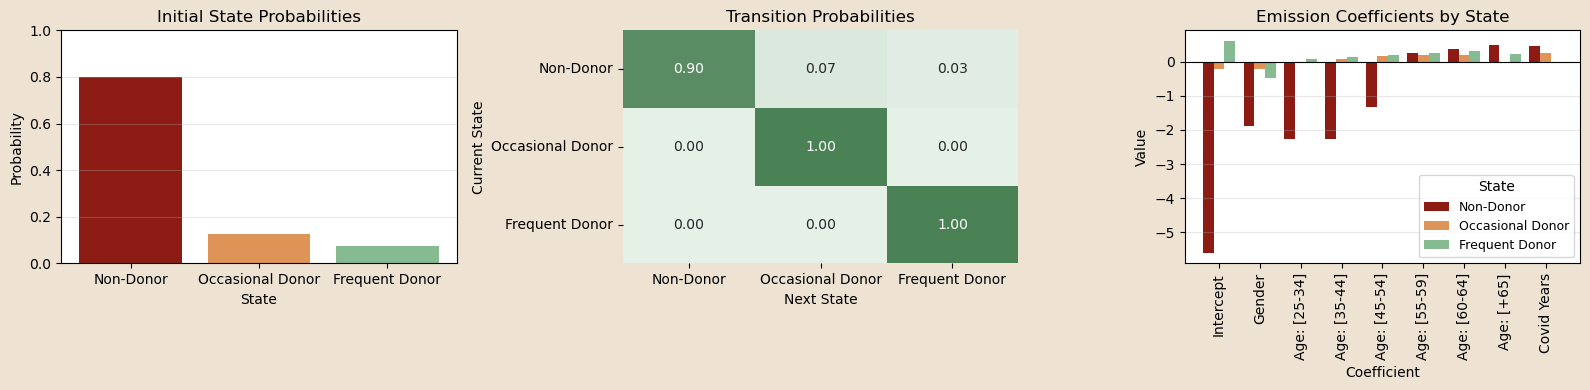

In [10]:
def softmax_row(v):
    e = np.exp(v - np.max(v, axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

# Covariate means
x_mean_pi = cov_init.mean(axis=0)

# Mean initial probs and transitions under average covariates
logits_pi = np.log(pi_base + 1e-30) + W_pi @ x_mean_pi
pi_mean   = softmax_row(logits_pi[None, :]).ravel() # ravel flats the dimensions from (1,N) to (N)


# Transition matrix building
# time alignament
prev_states = paths[:, :-1] 
x_tran_active = cov_tran[:, 1:, :] 

A_mean_viterbi = np.zeros((K, K))

for k in range(K):
    mask = (prev_states == k) 
    
    if mask.sum() > 0:
        x_mean_k = x_tran_active[mask].mean(axis=0)
    else:
        x_mean_k = np.zeros(C_A)
    
    logits_row = np.log(A_base[k] + 1e-30) + (W_A[k] @ x_mean_k)
    A_mean_viterbi[k] = softmax_row(logits_row[None, :]).ravel()

plots = hmm_pl.plot_hmm_params_with_coeffs(
    transitions=A_mean_viterbi,
    initial_probs=pi_mean,
    beta_em=beta_em,
    state_names=list(C.STATE_NAMES.values()),
    coeff_names=list(cov_names_em.values()),
    show=False    
)

Below the raw values for the number lovers.

In [11]:
print("Initial state probabilities")
print(plots["data"]["init"])

print("\nTransition probabilities")
print(plots["data"]["trans"])

print("\nCoefficients of GLMs")
print(plots["data"]["coeffs"])

Initial state probabilities
              state      prob
0         Non-Donor  0.799343
1  Occasional Donor  0.125474
2    Frequent Donor  0.075184

Transition probabilities
               from                to      prob
0         Non-Donor         Non-Donor  0.902560
1         Non-Donor  Occasional Donor  0.070352
2         Non-Donor    Frequent Donor  0.027087
3  Occasional Donor         Non-Donor  0.000043
4  Occasional Donor  Occasional Donor  0.998503
5  Occasional Donor    Frequent Donor  0.001454
6    Frequent Donor         Non-Donor  0.000001
7    Frequent Donor  Occasional Donor  0.002461
8    Frequent Donor    Frequent Donor  0.997537

Coefficients of GLMs
              state  Intercept    Gender  Age: [25-34]  Age: [35-44]  \
0         Non-Donor  -5.597002 -1.892894     -2.268111     -2.260499   
1  Occasional Donor  -0.226825 -0.205282     -0.037873      0.058881   
2    Frequent Donor   0.601927 -0.486156      0.061776      0.117469   

   Age: [45-54]  Age: [55-59]  Age:

## Covariates

### Coeficients' Heatmap

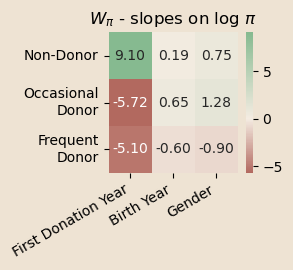

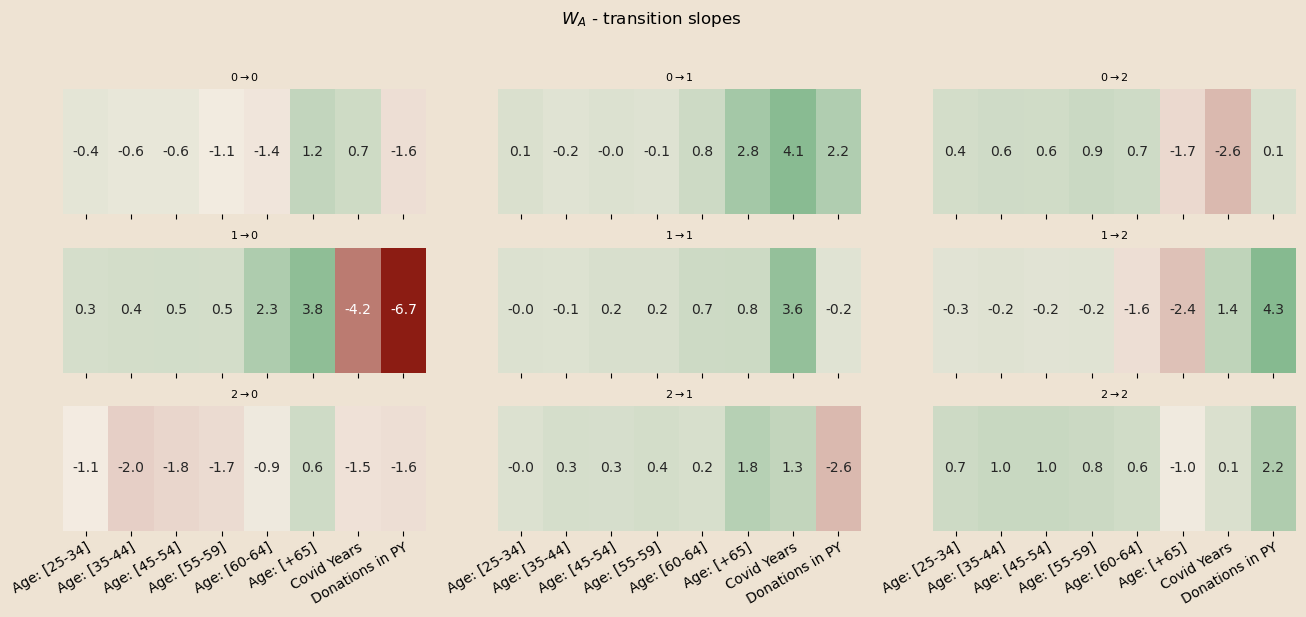

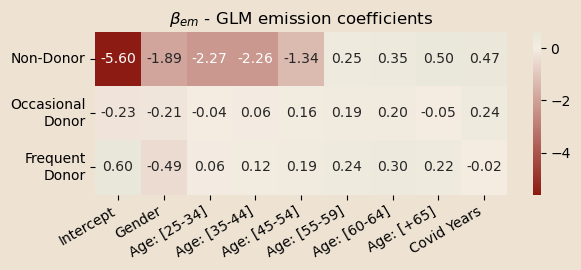

In [12]:
hmm_pl.plot_W_pi_heat(W_pi, cov_names_pi.values())
hmm_pl.plot_W_A_heat(W_A, cov_names_A.values())
hmm_pl.plot_beta_em_heat(beta_em, cov_names_em.values())

## Covariates - Marginal Effects

### Initial probabilities coefficients

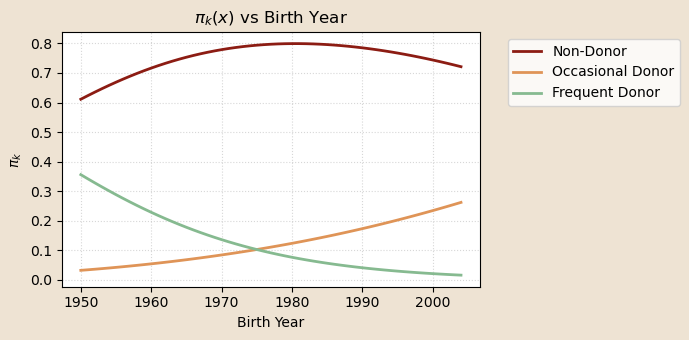

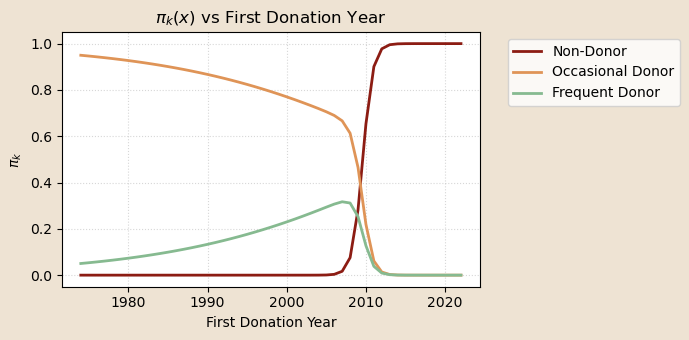

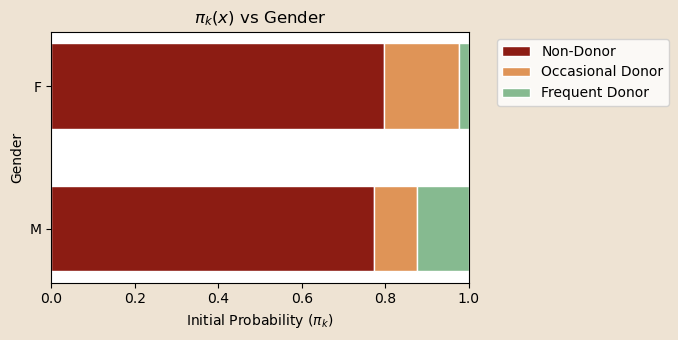

<module 'matplotlib.pyplot' from '/home/erikdeluca/miniforge3/envs/blood-donors/lib/python3.11/site-packages/matplotlib/pyplot.py'>

In [13]:
hmm_pl.plot_pi_vs_cov_orig("birth_year_norm", cov_names_pi, W_pi, pi_base, cov_init, birth_year_mean, birth_year_std)
hmm_pl.plot_pi_vs_cov_orig("first_donation_year_norm", cov_names_pi, W_pi, pi_base, cov_init, first_don_mean, first_don_std)
hmm_pl.plot_pi_vs_cov_orig("gender", cov_names_pi, W_pi, pi_base, cov_init, axes_label=["M", "F"])

### Transition matrix coefficients

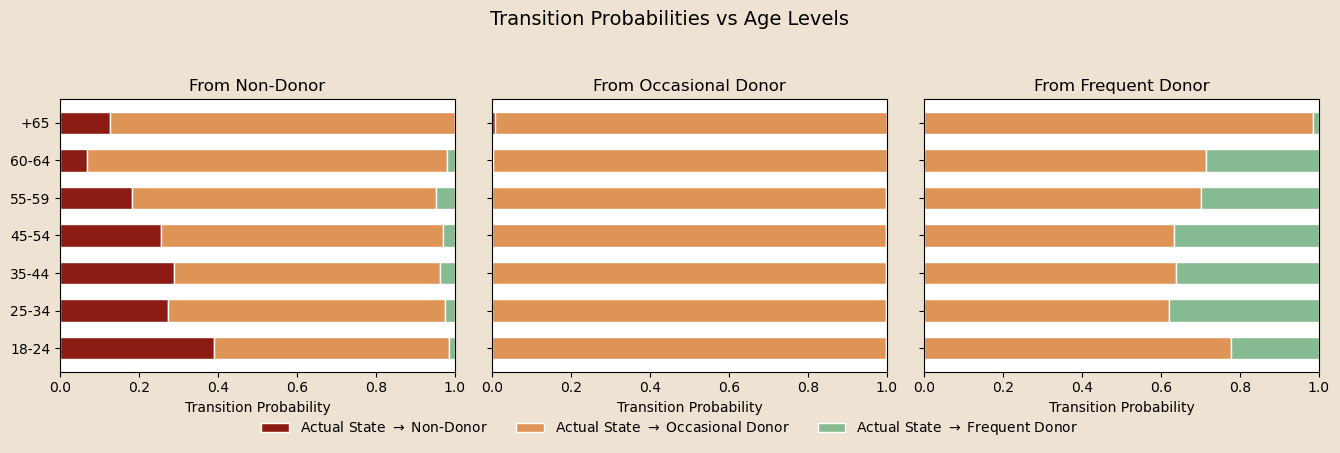

In [14]:
_ = hmm_pl.plot_trans_vs_cov_categorical(
    vars_list=[lev for lev in age_years_levels if lev != ref_age_level],
    cov_names_A=cov_names_A, 
    W_A=W_A, 
    log_A0=np.log(A_base),
    x_A_data=cov_tran,
    axes_label=["18-24"] + [lev for lev in age_years_levels if lev != ref_age_level],
    var_title="Age Levels"
)

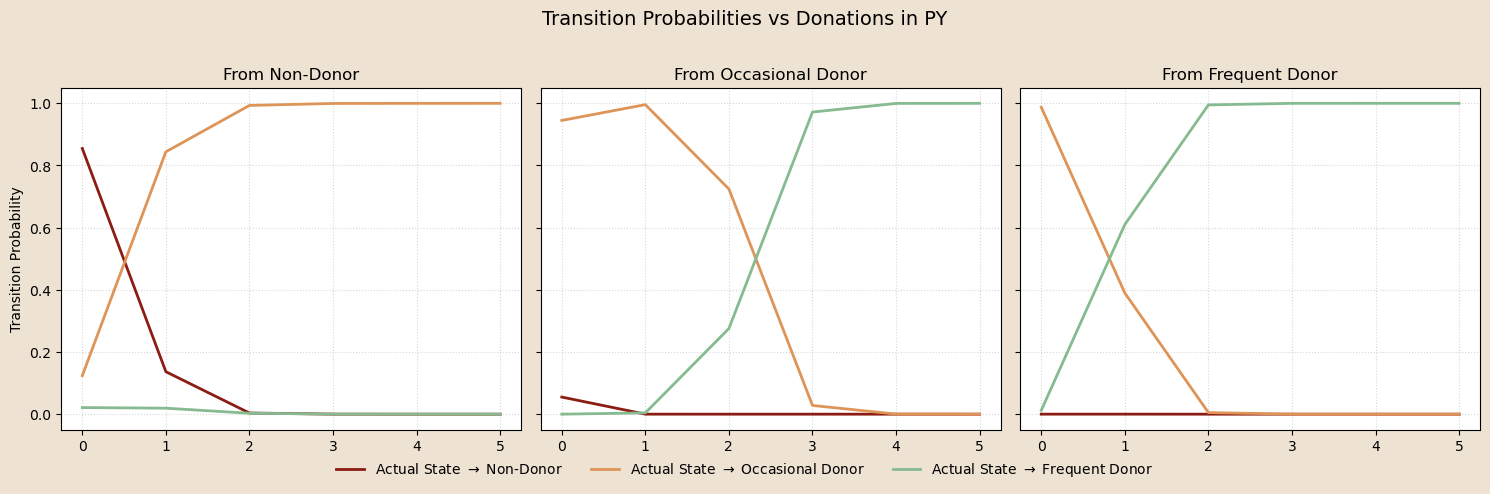

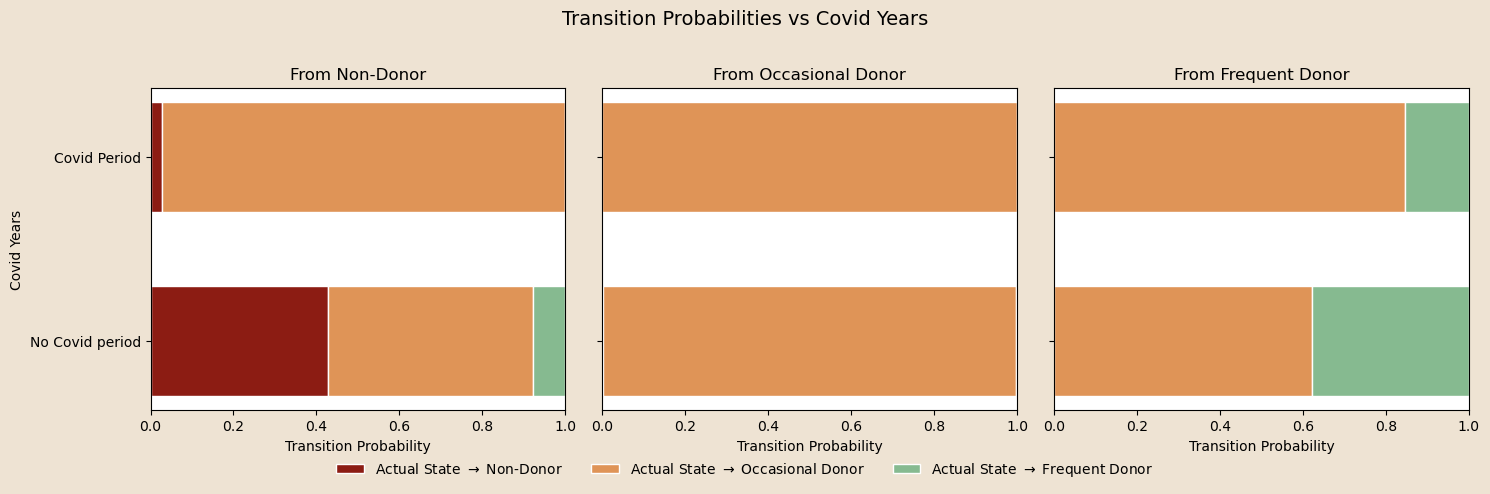

In [15]:
_ = hmm_pl.plot_trans_vs_cov_continuous(
    var="donations_py",
    cov_names_A=cov_names_A, 
    W_A=W_A, 
    log_A0=np.log(A_base),
    x_A_data=cov_tran
)
_ = hmm_pl.plot_trans_vs_cov_continuous(
    var="covid_years",
    cov_names_A=cov_names_A, 
    W_A=W_A, 
    log_A0=np.log(A_base),
    x_A_data=cov_tran,
    axes_label=["No Covid period", "Covid Period"]
)

### Emission coefficients

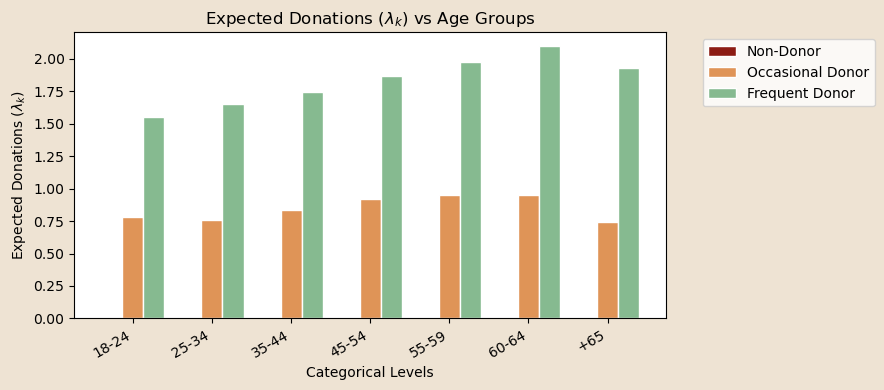

<module 'matplotlib.pyplot' from '/home/erikdeluca/miniforge3/envs/blood-donors/lib/python3.11/site-packages/matplotlib/pyplot.py'>

In [16]:
hmm_pl.plot_lambda_em_vs_cov_categorical(
    vars_list=[lev for lev in age_years_levels if lev != ref_age_level],
    cov_names_em=cov_names_em, 
    beta_em=beta_em, 
    x_em_data=cov_emission,
    axes_label=["18-24"] + [lev for lev in age_years_levels if lev != ref_age_level]
)

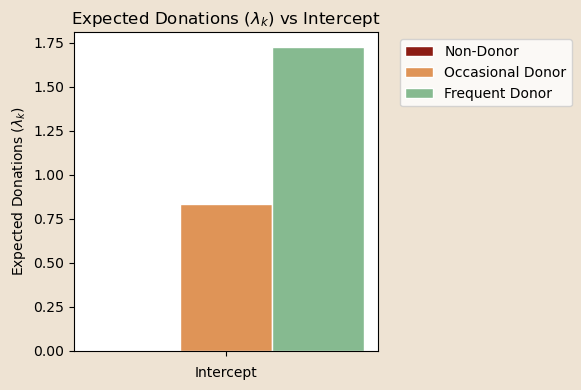

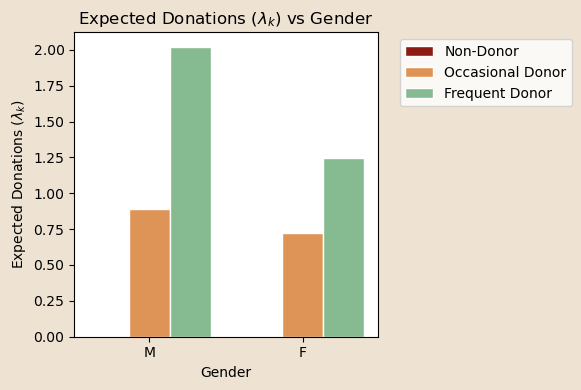

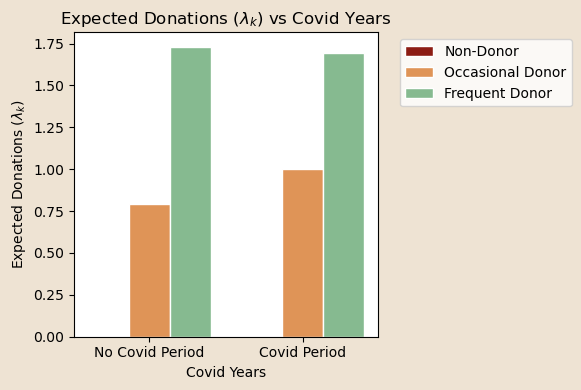

<module 'matplotlib.pyplot' from '/home/erikdeluca/miniforge3/envs/blood-donors/lib/python3.11/site-packages/matplotlib/pyplot.py'>

In [17]:
hmm_pl.plot_lambda_em_vs_cov_continuous(
    var="intercept",
    cov_names_em=cov_names_em, 
    beta_em=beta_em, 
    x_em_data=cov_emission,
    axes_label=[""]
)
hmm_pl.plot_lambda_em_vs_cov_continuous(
    var="gender",
    cov_names_em=cov_names_em, 
    beta_em=beta_em, 
    x_em_data=cov_emission,
    axes_label=["M", "F"]
)
hmm_pl.plot_lambda_em_vs_cov_continuous(
    var="covid_years",
    cov_names_em=cov_names_em, 
    beta_em=beta_em, 
    x_em_data=cov_emission,
    axes_label=["No Covid Period", "Covid Period"]
)

## State Occupancy Over Time

### Population View

Looking the plot, it's easy to detect a strong movement from state of "Non-Donor" to state of "Occasional Donor" during the covid years. 

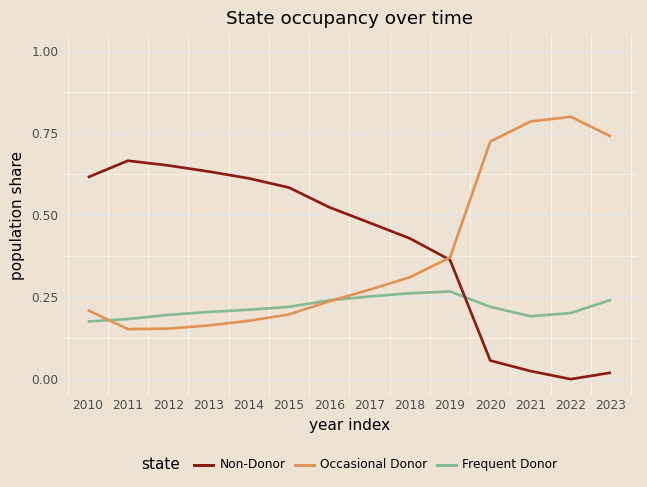

In [18]:
# Counts per state over time
counts = np.stack([(paths == k).sum(axis=0) for k in range(K)], axis=0)
props = counts / np.maximum(counts.sum(axis=0, keepdims=True), 1)  # avoid div-by-zero

rows = []
for k in range(K):
    for t in range(T):
        rows.append({"t": t, "state": C.STATE_NAMES[k], "share": float(props[k, t])})
occupancy = pd.DataFrame(rows)

(
    pn.ggplot(occupancy, pn.aes("t", "share", color="state"))
    + pn.geom_line(size=1.1)
    + pn.scale_color_manual(
        values=list(C.STATE_PALETTE.values()),
        breaks=list(C.STATE_NAMES.values()),
        name="state",
        # labels=list(C.STATE_NAMES.values())
        )
    + pn.scale_x_continuous(breaks=list(range(T)), labels=years_num)
    + pn.scale_y_continuous(limits=(0, 1))
    + pn.labs(x="year index", y="population share", title="State occupancy over time")
    + pn.theme_minimal()
    + pn.theme(
        axis_text_x=pn.element_text(rotation=0),
        legend_position="bottom",
        )
)

### Individual trajectories

Pick a few donors and overlay observations + decoded state for an easy interpretation of the model.

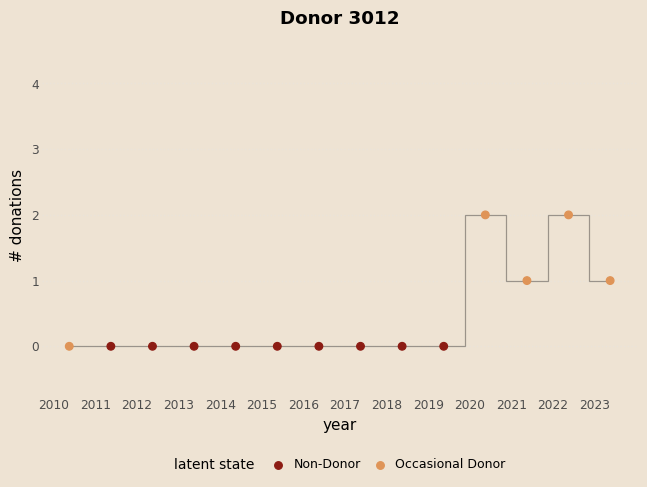

In [19]:
hmm_pl.plot_one_gg(
        idx=3012,
        obs=obs,
        paths=paths,
        years=years_num
    )

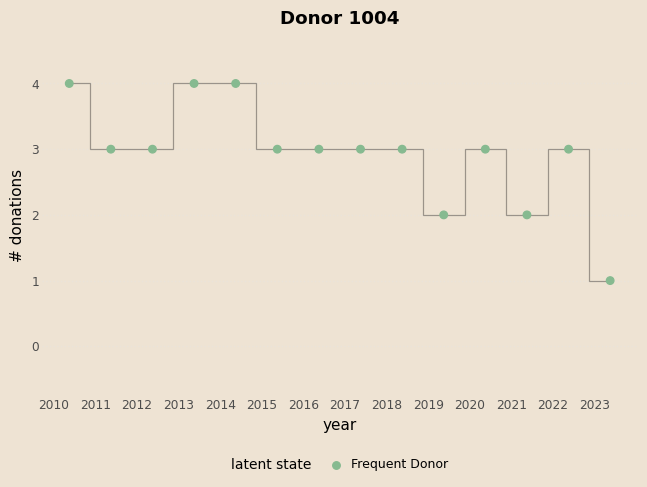

In [20]:
hmm_pl.plot_one_gg(
        idx=1004,
        obs=obs,
        paths=paths,
        years=years_num,
    )

## Predictions

To calculate the predictions, given a new observation, we'll need to do again the data wrangling, like normalize continuous variables, code factor variables, ...
This step is done by the function `prepare_donor_data()`. This function need to know the original mean and standard deviation used for the normalization of the continuous variables, but it's very flexilble in the other aspects. The dimension of the time series is flexible, so the user can just enter a few value, as in the example below.

For the prediction, in the `predict_hmm_donor()`, we calculate in the same cycle the Forward algorithm and Viterbi's algortihm. The first one is used to calculate the $\alpha$ probabilities to belong to each state at the time $T+1$. While, the second one, it give us, for each time $t$, the most probable state to belong at that time.
In this function the prediction is given as the mixture of the different GLM's models at the time $T+1$, weighted by the $\alpha$ probabilities.   

                2018              2019              2020              2021
Donations          0                 1                 0                 2
State      Non-Donor  Occasional Donor  Occasional Donor  Occasional Donor

Prob. to donate (>0): 0.6734

           0       1       2       3    >=4
PMF:  0.3266  0.3594  0.2022  0.0787  0.033


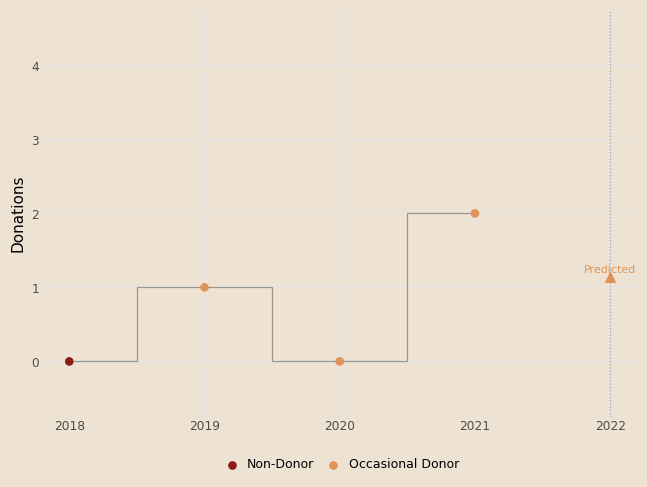

In [21]:
model_params = (W_pi, W_A, pi_base, A_base, beta_em)

obs_donor, x_pi_donor, xA_h, xem_h, xA_n, xem_n, next_yr_donor = hmm_glm.prepare_donor_data(
    birth_year=1985,
    gender="M",
    first_donation_year=2015,
    history_years=[2018, 2019, 2020, 2021],
    history_counts=[0, 1, 0, 2],
    birth_year_mean=birth_year_mean,
    birth_year_std=birth_year_std,
    first_don_mean=first_don_mean,
    first_don_std=first_don_std,
    donation_py_init=1
)

results = hmm_glm.predict_hmm_donor(
    obs=obs_donor, 
    x_pi=x_pi_donor, 
    x_A_hist=xA_h, 
    x_em_hist=xem_h, 
    x_A_next=xA_n, 
    x_em_next=xem_n, 
    model_params=model_params,
    years=[2018, 2019, 2020, 2021],
    )

print(results["history_df"])
print(f"\nProb. to donate (>0): {results['prob_donate_next']}")
print(f"\n{pd.DataFrame([results['pmf_next']], index=['PMF:'])}")

hmm_pl.plot_donor_gg(results)

The model is able to catch long periods where the donor wasn't donating and then, it can *reactivate* again at the first donation.

,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Donations,0,1,0,0,0,0,0,0,0,0,1,0,1,0,1
State,Occasional Donor,Occasional Donor,Occasional Donor,Non-Donor,Non-Donor,Non-Donor,Non-Donor,Non-Donor,Non-Donor,Non-Donor,Occasional Donor,Occasional Donor,Occasional Donor,Occasional Donor,Occasional Donor



Prob. to donate (>0): 0.5338

           0       1       2       3     >=4
PMF:  0.4662  0.3554  0.1358  0.0347  0.0079


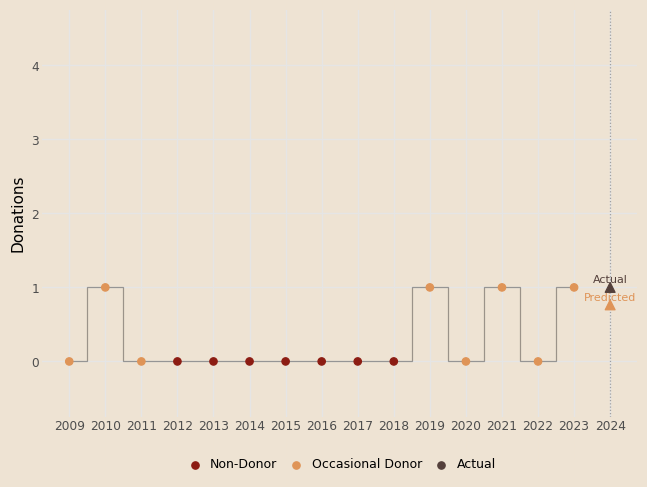

In [22]:
donor_birth_year_obs = 1970
donor_gender_obs = "F"
first_donation_obs = 1990
history_years   = list(range(2009, 2024))
history_counts  = [0,1,0,0,0,0,0,0,0,0,1,0,1,0,1]
next_year = 2024
donation_py_init_obs = 0

obs_donor, x_pi_donor, xA_h, xem_h, xA_n, xem_n, next_yr_donor = hmm_glm.prepare_donor_data(
    birth_year=donor_birth_year_obs,
    gender=donor_gender_obs,
    first_donation_year=first_donation_obs,
    history_years=history_years,
    history_counts=history_counts,
    birth_year_mean=birth_year_mean,
    birth_year_std=birth_year_std,
    first_don_mean=first_don_mean,
    first_don_std=first_don_std,
    donation_py_init=donation_py_init_obs
)

results = hmm_glm.predict_hmm_donor(
    obs=obs_donor, 
    x_pi=x_pi_donor, 
    x_A_hist=xA_h, 
    x_em_hist=xem_h, 
    x_A_next=xA_n, 
    x_em_next=xem_n, 
    model_params=model_params,
    years=history_years,
    )

display(results["history_df"])
print(f"\nProb. to donate (>0): {results['prob_donate_next']}")
print(f"\n{pd.DataFrame([results['pmf_next']], index=['PMF:'])}")

y_true_next = 1
p = hmm_pl.plot_donor_gg(
    results,
    y_true_next
)
p

A limitation of the model is that it is more propense to predict values smaller then the bigger. 

,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
Donations,0,0,3,4,3,4,3,4,3,2,2,2,3
State,Non-Donor,Non-Donor,Frequent Donor,Frequent Donor,Frequent Donor,Frequent Donor,Frequent Donor,Frequent Donor,Frequent Donor,Frequent Donor,Frequent Donor,Frequent Donor,Frequent Donor



Predizione anno: 2023

Prob. di donare (>0): 0.8565

           0       1       2      3     >=4
PMF:  0.1435  0.2785  0.2704  0.175  0.1325


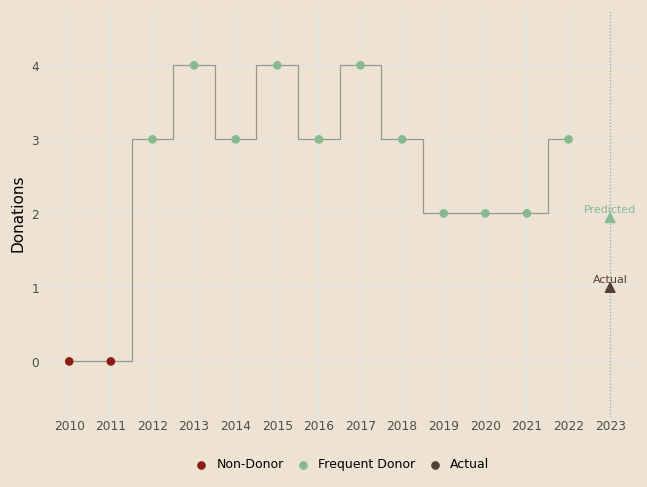

In [23]:
idx = 4011

results = hmm_glm.predict_hmm_donor(
    obs=obs[idx, :-1], 
    x_pi=cov_init[idx, :], 
    x_A_hist=cov_tran[idx, :-1, :], 
    x_em_hist=cov_emission[idx, :-1, :], 
    x_A_next=cov_tran[idx, -1, :], 
    x_em_next=cov_emission[idx, -1, :], 
    model_params=model_params,
    years=years_num,
)

display(results["history_df"])
print(f"\nPredizione anno: {results['next_year']}")
print(f"\nProb. di donare (>0): {results['prob_donate_next']}")
print(f"\n{pd.DataFrame([results['pmf_next']], index=['PMF:'])}")

y_true_next = int(obs[idx, -1])
p = hmm_pl.plot_donor_gg(
    results,
    y_true_next
)
p

# Train and test

Let's split the DB into 2 parts, one will be used for the training and the other one for the testing.
After the training of the model the test part will be used to get the probabilities about the donor and its donation the next year.

In [24]:
# cycles = 2000
# param_path = here("models/hmm_glm_improved_train.pt")

# pyro.clear_param_store()
# svi = SVI(hmm_glm_improved, guide_hmm_glm_improved,
#           Adam({"lr": 2e-2}),
#           loss=TraceEnum_ELBO(max_plate_nesting=1))

# for step in range(cycles):
#     loss = svi.step(obs_train_torch, xpi_train_torch, xA_train_torch, xem_train_torch)
#     if step % round(cycles / 15) == 0:
#         print(f"{step:4d}  ELBO = {loss:,.0f}")

# pyro.get_param_store().save(param_path)
# print(f"ParamStore saved in: {param_path}")

In [25]:
# cycles = 2000
# param_path = here("models/hmm_glm_improved_test.pt")

# pyro.clear_param_store()
# svi = SVI(hmm_glm_improved, guide_hmm_glm_improved,
#           Adam({"lr": 2e-2}),
#           loss=TraceEnum_ELBO(max_plate_nesting=1))

# for step in range(cycles):
#     loss = svi.step(obs_test_torch, xpi_test_torch, xA_test_torch, xem_test_torch)
#     if step % round(cycles / 15) == 0:
#         print(f"{step:4d}  ELBO = {loss:,.0f}")

# pyro.get_param_store().save(param_path)
# print(f"ParamStore saved in: {param_path}")

Load the model and store the parameters

In [26]:
W_pi_train, W_A_train, pi_base_train, A_base_train, beta_em_train = hmm_glm.load_hmm_params(here("models/hmm_glm_improved_train.pt"))
W_pi_test, W_A_test, pi_base_test, A_base_test, beta_em_test = hmm_glm.load_hmm_params(here("models/hmm_glm_improved_test.pt"))

We calculated several metrics on both the training and test sets to evaluate the predictive performance and generalization capabilities of our model.

The mean log-likelihood is slightly higher (less negative) in the test set (-12.388 vs -12.600), and the Negative Log-Likelihood (NLL) shows a similarly consistent trend (0.732 vs 0.751). This demonstrates a complete absence of overfitting, indicating that the latent structure learned by the model generalizes perfectly to unseen sequences.

The Mean Absolute Error (MAE) shows that the model predicts the yearly donation count with an average error of $\approx 0.75$ donations. This is a robust result, indicating that predictions generally deviate by less than one donation from the ground truth. Furthermore, the Root Mean Square Error (RMSE) remains well-controlled ($\approx 1.02$); this tells us that the model does not produce extreme prediction errors (outliers), successfully handling a response variable that assumes discrete values between 0 and 4. 

Finally, we evaluated the Brier score for the binary event of "donating at least once" ($y > 0$). The score is $\approx 0.416$ on the test set. Compared to a random-guess baseline (0.50), this result demonstrates that the fully trained model captures a meaningful predictive edge regarding donor return probability, while correctly preserving the intrinsic, irreducible stochasticity of human behavior in blood donation.

In [27]:
params_train = (W_pi_train, W_A_train, pi_base_train, A_base_train, beta_em_train)
params_test = (W_pi_test, W_A_test, pi_base_test, A_base_test, beta_em_test)

ll_train = hmm_glm.forward_loglik_cov(obs_train, xpi_train, xA_train, xem_train, model_path=here("models/hmm_glm_improved_train.pt"))
ll_test = hmm_glm.forward_loglik_cov(obs_test, xpi_test, xA_test, xem_test, model_path=here("models/hmm_glm_improved_train.pt"))

metrics_train = hmm_glm.one_step_ahead_metrics(obs_train, xpi_train, xA_train, xem_train, model_path=here("models/hmm_glm_improved_test.pt"))
metrics_test = hmm_glm.one_step_ahead_metrics(obs_test, xpi_test, xA_test, xem_test, model_path=here("models/hmm_glm_improved_test.pt"))


mll_train = ll_train.mean().item()
mll_test = ll_test.mean().item()

metrics_train["Log-Lik"] = mll_train
metrics_test["Log-Lik"] = mll_test

results_df = pd.DataFrame(
    [metrics_train, metrics_test], 
    index=["Train", "Test"]
)

columns_order = ["Log-Lik", "NLL", "MAE", "RMSE", "Brier(y>0)"]
results_df = results_df[columns_order].round(3)

results_df

,Log-Lik,NLL,MAE,RMSE,Brier(y>0)
Train,-12.600,0.928,0.542,0.776,0.137
Test,-12.429,0.908,0.529,0.762,0.132


## Comparison with a GLM

### GLM Poisson in Pyro

Let's define a vanilla GLM to check the results versus our model. 
Even thought is a easy model and it could be defined manually, or with simpler libraries, we decided to define it via Pyro.

- $y \sim \mathrm{Poisson}(\mu)$
- $\log \mu = \beta_0 + \beta_1 \text{birth\_year\_norm} + \beta_2 \text{gender}$

In [28]:
# Poisson GLM with log link
def glm_poisson_model(X, y=None):
    N, C = X.shape
    beta = pyro.param("glm_beta", torch.zeros(C))  # intercept + C slopes
    log_mu = (X @ beta[:].unsqueeze(-1)).squeeze(-1)         # (N,)
    mu = log_mu.exp()
    with pyro.plate("data", N):
        pyro.sample("obs", dist.Poisson(mu), obs=y)

def glm_poisson_guide(X, y=None):
    # Mean-field guide is empty: we use point estimates via pyro.param in the model.
    pass

# Train
def fit_glm_poisson(X, y, steps=3000, lr=1e-2, verbose_every=500, save_path=here("python/glm_poisson_improved_params.pt")):
    X = X.detach()
    y = y.detach().float()
    pyro.clear_param_store()
    svi = SVI(
        lambda X_, y_: glm_poisson_model(X_, y_),
        lambda X_, y_: glm_poisson_guide(X_, y_),
        Adam({"lr": lr}),
        loss=Trace_ELBO()
    )
    loss_hist = []
    for s in range(steps):
        loss = svi.step(X, y)
        if verbose_every and s % verbose_every == 0:
            print(f"step {s:4d}: loss={loss:.3f}")
        loss_hist.append(loss)
    pyro.get_param_store().save(save_path)
    return loss_hist

# Predict and metrics
@torch.no_grad()
def glm_poisson_predict(X, beta, return_proba=False):
    X = X.detach()
    log_mu = (X @ beta[:].unsqueeze(-1)).squeeze(-1)
    mu = log_mu.exp()  # expected counts
    if return_proba:
        p_donate = 1.0 - torch.exp(-mu)
        return mu, p_donate
    return mu

@torch.no_grad()
def glm_poisson_evaluate_hmmstyle(X, y, beta):
    """
    Metrics aligned with the HMM printout:
      - pred mean
      - obs mean
      - MSE
      - Accuracy (round)
    """
    X = X.detach()
    y_f = y
    mu = glm_poisson_predict(X, beta, return_proba=False)  # (N,)

    # HMM-style metrics
    pred_mean = mu.mean().item()
    obs_mean  = y_f.mean().item()
    mse = torch.mean((mu - y_f) ** 2).item()
    acc_round = torch.mean((torch.round(mu) == y_f).float()).item()

    return {
        "pred mean": pred_mean,
        "obs mean": obs_mean,
        "MSE": mse,
        "Accuracy (round)": acc_round,
    }


In [29]:
# y_train: last-year counts, X_train: corresponding covariates
y_train = obs_train_torch[:, -1].float()
X_train = xem_train_torch[:, -1, :]

y_test = obs_test_torch[:, -1].float()
X_test = xem_test_torch[:, -1, :]

# loss_hist = fit_glm_poisson(X_train, y_train, steps=2000, lr=1e-1, verbose_every=200)
pyro.get_param_store().load(here("python/glm_poisson_improved_params.pt"))
glm_beta = pyro.param("glm_beta")
y_pred_glm = glm_poisson_predict(X_test, glm_beta)
pred_glm = glm_poisson_predict(X_test, glm_beta, return_proba=True)

### Hold-out Forecast Evaluation

#### HMM multi-state vs GLM

In [30]:
y_test_final = obs_test[:, -1]
results_final = hmm_glm.one_step_ahead(obs_test, xpi_test, xA_test, xem_test, model_path=here("models/hmm_glm_improved_train.pt"), pick_one_state=False)
y_pred_hmm_final = results_final["y_expected"][:,-1]

hmm_metrics = hmm_glm.build_hmm_metrics(y_pred_hmm_final, y_test_final)
glm_metrics = hmm_glm.build_hmm_metrics(pred_glm, y_test_final) 

hmm_glm.print_comparison_table(glm_metrics, hmm_metrics)

Metric                        GLM          HMM   Diff (HMM-GLM)   Rel diff %
---------------------------------------------------------------------------
pred mean                    0.78         1.09             0.30       38.50%
obs mean                     0.99         0.99             0.00        0.00%
MSE                        1.1632       0.7557          -0.4075      -35.03%
Accuracy (round)           30.00%       33.76%          3.76 pp       12.54%


In [31]:
(np.round(results_final["y_expected"][:,-1], 0) == results_final["y_true"][:,-1]).sum() /  results_final["y_true"].shape[0]

np.float64(0.33763440860215055)

#### HMM one-state vs GLM

In [32]:
y_test_final = obs_test[:, -1]
results_final = hmm_glm.one_step_ahead(obs_test, xpi_test, xA_test, xem_test, model_path=here("models/hmm_glm_improved_train.pt"), pick_one_state=True)
y_pred_hmm_final = results_final["y_expected"][:,-1]

hmm_metrics = hmm_glm.build_hmm_metrics(y_pred_hmm_final, y_test_final)
glm_metrics = hmm_glm.build_hmm_metrics(pred_glm, y_test_final) 

hmm_glm.print_comparison_table(glm_metrics, hmm_metrics)

Metric                        GLM          HMM   Diff (HMM-GLM)   Rel diff %
---------------------------------------------------------------------------
pred mean                    0.78         1.07             0.29       36.69%
obs mean                     0.99         0.99             0.00        0.00%
MSE                        1.1632       0.8043          -0.3590      -30.86%
Accuracy (round)           30.00%       31.61%          1.61 pp        5.38%


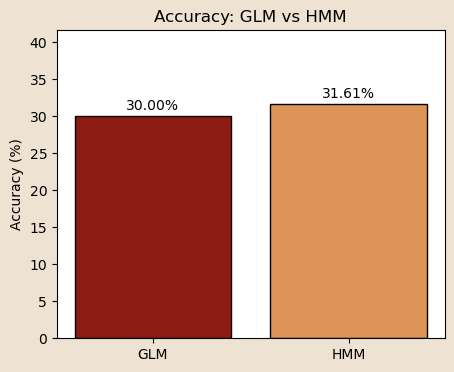

In [33]:
hmm_pl.plot_accuracy(glm_metrics["Accuracy (round)"], hmm_metrics["Accuracy (round)"]) 

In [34]:
y_test_final = np.asarray(obs_test[:, -1]).ravel()

# HMM Multi-State
results_ms = hmm_glm.one_step_ahead(
    obs_test, xpi_test, xA_test, xem_test, 
    model_path=here("models/hmm_glm_improved_train.pt"), 
    pick_one_state=False
)
y_pred_hmm_ms = np.asarray(results_ms["y_expected"][:, -1]).ravel()
error_hmm_ms = y_pred_hmm_ms - y_test_final

# HMM One-State
results_os = hmm_glm.one_step_ahead(
    obs_test, xpi_test, xA_test, xem_test, 
    model_path=here("models/hmm_glm_improved_train.pt"), 
    pick_one_state=True
)
y_pred_hmm_os = np.asarray(results_os["y_expected"][:, -1]).ravel()
error_hmm_os = y_pred_hmm_os - y_test_final

# GLM
error_glm = y_pred_glm - y_test_final

glm_metrics = hmm_glm.build_hmm_metrics(pred_glm, y_test_final) 
hmm_metrics_ms = hmm_glm.build_hmm_metrics(y_pred_hmm_ms, y_test_final)


print("GLM vs HMM (Multi-State Mixture)")
hmm_glm.print_comparison_table(glm_metrics, hmm_metrics_ms)


GLM vs HMM (Multi-State Mixture)
Metric                        GLM          HMM   Diff (HMM-GLM)   Rel diff %
---------------------------------------------------------------------------
pred mean                    0.78         1.09             0.30       38.50%
obs mean                     0.99         0.99             0.00        0.00%
MSE                        1.1632       0.7557          -0.4075      -35.03%
Accuracy (round)           30.00%       33.76%          3.76 pp       12.54%


<positron-console-cell-34>:22: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)


<positron-console-cell-35>:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.


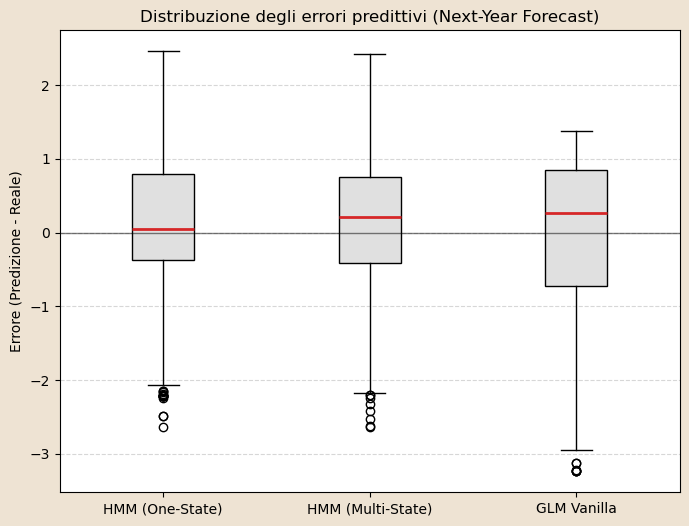

In [35]:

plt.figure(figsize=(8, 6))

plt.boxplot(
    [error_hmm_os, error_hmm_ms, error_glm], 
    labels=["HMM (One-State)", "HMM (Multi-State)", "GLM Vanilla"],
    patch_artist=True, 
    boxprops=dict(facecolor="#e0e0e0", color="black"),
    medianprops=dict(color="#d62728", linewidth=2)
)

# Linea dello zero
plt.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)

plt.ylabel("Errore (Predizione - Reale)")
plt.title("Distribuzione degli errori predittivi (Next-Year Forecast)")
plt.grid(True, linestyle="--", alpha=0.5, axis='y')
plt.show()

In [36]:

df_pred = pd.DataFrame({
    "y_pred_hmm_multi_state": y_pred_hmm_ms,
    "y_pred_hmm_one_state": y_pred_hmm_os,
    "y_test": y_test,
    # "y_test": y_test.detach().cpu().numpy().ravel(),
    "y_pred_glm": torch.round(y_pred_glm).int().detach().cpu().numpy().ravel(),
})
df_pred["error_hmm_ms"] = df_pred["y_pred_hmm_multi_state"].round() - df_pred["y_test"]
df_pred["error_hmm_os"] = df_pred["y_pred_hmm_one_state"].round() - df_pred["y_test"]
df_pred["error_glm"] = df_pred["y_pred_glm"].round() - df_pred["y_test"]
df_pred["error_glm_rounded"] = df_pred["error_glm"].astype(int)
df_pred["error_hmm_ms_rounded"] = df_pred["error_hmm_ms"].astype(int)
df_pred["error_hmm_os_rounded"] = df_pred["error_hmm_os"].astype(int)

df_pred.to_csv(here("models/metrics_df_thesis.csv"), index=False)

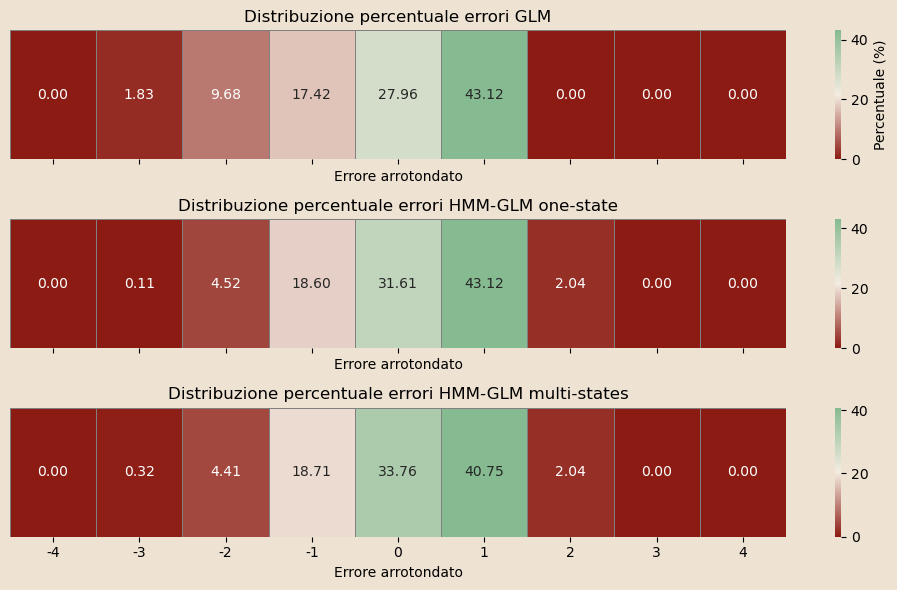

In [37]:
import seaborn as sns

def plot_error_distribution(errors, title, ax):
    full_range = pd.Series(range(-4,5), name="error")
    freq = errors.value_counts(normalize=True).sort_index() * 100
    freq_df = freq.reset_index()
    freq_df.columns = ["error", "percent"]
    freq_df = full_range.to_frame().merge(freq_df, on="error", how="left").fillna(0)
    pivot_df = freq_df.pivot_table(index="error", values="percent")
    sns.heatmap(
        pivot_df.T,
        annot=True,
        fmt=".2f",
        cmap=hmm_pl.COEFF_CMAP,
        cbar_kws={'label': 'Percentuale (%)'} if title=="GLM" else None,
        linewidths=0.5,
        linecolor='gray',
        ax=ax,
        vmin=0, vmax=freq_df["percent"].max()  # uniform color scale
    )
    ax.set_xlabel("Errore arrotondato")
    ax.set_ylabel("")
    ax.set_yticks([])
    ax.set_title(f"Distribuzione percentuale errori {title}")
    ax.set_xticklabels(range(-4,5))

fig, axes = plt.subplots(3,1, figsize=(10,6), sharex=True)
plot_error_distribution(df_pred["error_glm_rounded"], "GLM", axes[0])
plot_error_distribution(df_pred["error_hmm_os_rounded"], "HMM-GLM one-state", axes[1])
plot_error_distribution(df_pred["error_hmm_ms_rounded"], "HMM-GLM multi-states", axes[2])

plt.tight_layout()
plt.show()

### ROC Curve

The plot show how good is the model in the prediction if a donor next year is going to donate or less. The model is not performing very well in this scenario

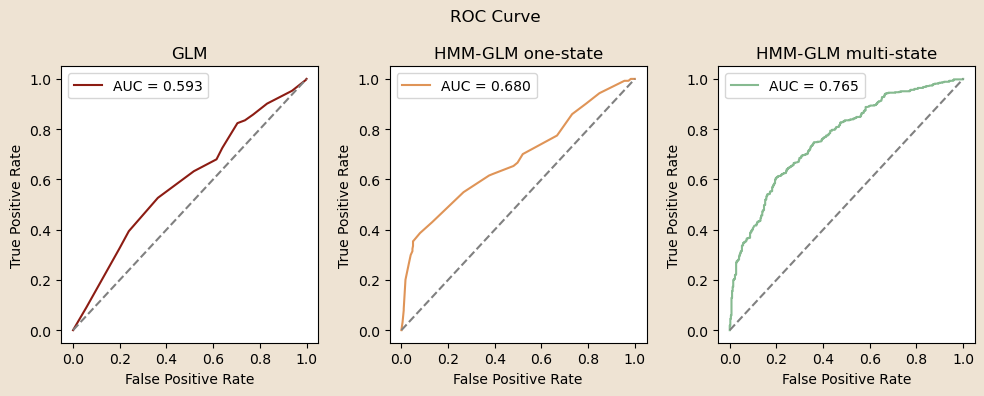

In [38]:
hmm_pl.plot_roc_auc(
    y_test,
    [y_pred_glm, y_pred_hmm_os, y_pred_hmm_ms]
)